# Laboratorio 10

In [1]:
import os
import inspect
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.semi_supervised import SelfTrainingClassifier, LabelSpreading
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")
os.makedirs("outputs", exist_ok=True)

DATA_PATH = os.path.join("data", "data.csv")
if not os.path.exists(DATA_PATH):
    DATA_PATH = "data.csv"

RANDOM_STATE = 42
SAMPLE_SIZE = 6000
LABELED_PERCENTAGES = [0.05, 0.10, 0.20]

## Inciso 1

In [2]:
df = pd.read_csv(DATA_PATH)
df = df.drop(columns=[c for c in df.columns if c.lower().startswith("unnamed")], errors="ignore")

print("Dimensiones del dataset:", df.shape)
print("Columnas:", list(df.columns))

tipos = pd.DataFrame({
    "columna": df.columns,
    "tipo": [str(df[c].dtype) for c in df.columns],
    "nulos": [df[c].isna().sum() for c in df.columns],
    "unicos": [df[c].nunique(dropna=True) for c in df.columns]
})

display(tipos)
display(df.head())
display(df.describe(include="all").T)

Dimensiones del dataset: (2965561, 6)
Columnas: ['host', 'time', 'method', 'url', 'response', 'bytes']


,columna,tipo,nulos,unicos
0,host,object,0,135268
1,time,int64,0,1834645
2,method,object,0,3
3,url,object,0,365
4,response,int64,0,5
5,bytes,int64,0,10192


,host,time,method,url,response,bytes
0,***.novo.dk,805465029,GET,/ksc.html,200,7067
1,***.novo.dk,805465031,GET,/images/ksclogo-medium.gif,200,5866
2,***.novo.dk,805465051,GET,/images/MOSAIC-logosmall.gif,200,363
3,***.novo.dk,805465053,GET,/images/USA-logosmall.gif,200,234
4,***.novo.dk,805465054,GET,/images/NASA-logosmall.gif,200,786


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
host,2965561,135268,piweba3y.prodigy.com,19258,NaN,NaN,NaN,NaN,NaN,NaN,NaN
time,2965561.0,NaN,NaN,NaN,807075128.248049,1666640.343821,804571201.0,805592147.0,806731982.0,808590801.0,809927993.0
method,2965561,3,GET,2957882,NaN,NaN,NaN,NaN,NaN,NaN,NaN
url,2965561,365,/images/NASA-logosmall.gif,208798,NaN,NaN,NaN,NaN,NaN,NaN,NaN
response,2965561.0,NaN,NaN,NaN,209.559685,30.487431,200.0,200.0,200.0,200.0,501.0
bytes,2965561.0,NaN,NaN,NaN,14553.731228,60054.916215,0.0,669.0,3381.0,8677.0,6823936.0


In [3]:
datos = df.copy()
datos["response"] = pd.to_numeric(datos["response"], errors="coerce")
datos["bytes"] = pd.to_numeric(datos["bytes"], errors="coerce")
datos["time"] = pd.to_numeric(datos["time"], errors="coerce")

datos["datetime"] = pd.to_datetime(datos["time"], unit="s", errors="coerce")
datos["hour"] = datos["datetime"].dt.hour.fillna(-1).astype(int)
datos["dayofweek"] = datos["datetime"].dt.dayofweek.fillna(-1).astype(int)
datos["url_text"] = datos["url"].astype(str)
datos["host_text"] = datos["host"].astype(str)
datos["url_length"] = datos["url_text"].str.len()
datos["url_depth"] = datos["url_text"].str.count("/")
datos["has_query"] = datos["url_text"].str.contains(r"\?", regex=True).astype(int)
datos["host_length"] = datos["host_text"].str.len()
datos["bytes_log"] = np.log1p(datos["bytes"].clip(lower=0))
datos["extension"] = datos["url_text"].str.extract(r"\.([A-Za-z0-9]+)(?:$|\?)", expand=False).str.lower().fillna("sin_extension")
top_extensiones = datos["extension"].value_counts().head(15).index
datos["extension_top"] = np.where(datos["extension"].isin(top_extensiones), datos["extension"], "otra")
datos["target"] = np.where(datos["response"] == 200, "exitosa", "no_exitosa")

columnas_modelo = ["bytes", "bytes_log", "hour", "dayofweek", "url_length", "url_depth", "has_query", "host_length", "method", "extension_top", "target"]
datos_modelo = datos[columnas_modelo].replace([np.inf, -np.inf], np.nan).dropna()

if len(datos_modelo) > SAMPLE_SIZE:
    _, datos_modelo = train_test_split(
        datos_modelo,
        test_size=SAMPLE_SIZE,
        stratify=datos_modelo["target"],
        random_state=RANDOM_STATE
    )

print("Dimensiones usadas para el experimento:", datos_modelo.shape)
display(datos_modelo.head())
display(datos_modelo["target"].value_counts(normalize=True).rename("proporcion").to_frame())

Dimensiones usadas para el experimento: (6000, 11)


,bytes,bytes_log,hour,dayofweek,url_length,url_depth,has_query,host_length,method,extension_top,target
2293863,1713,7.446585,16,4,23,2,0,23,GET,gif,exitosa
1239883,509,6.234411,21,3,16,2,0,27,GET,xbm,exitosa
467293,18114,9.804496,16,4,40,4,0,14,GET,html,exitosa
355993,0,0.000000,13,1,16,2,0,14,GET,htm,no_exitosa
803438,3260,8.089789,22,6,27,3,0,23,GET,html,exitosa


,proporcion
target,
exitosa,0.909333
no_exitosa,0.090667


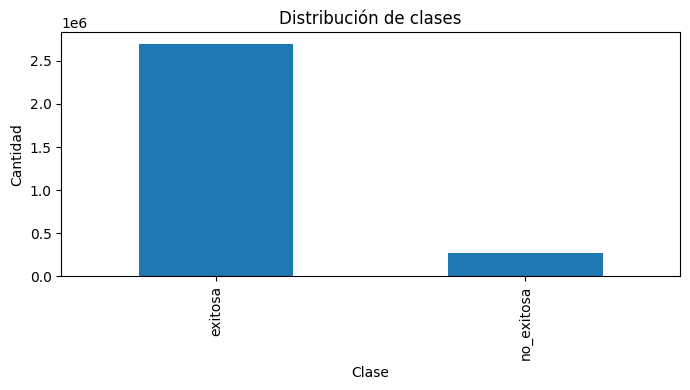

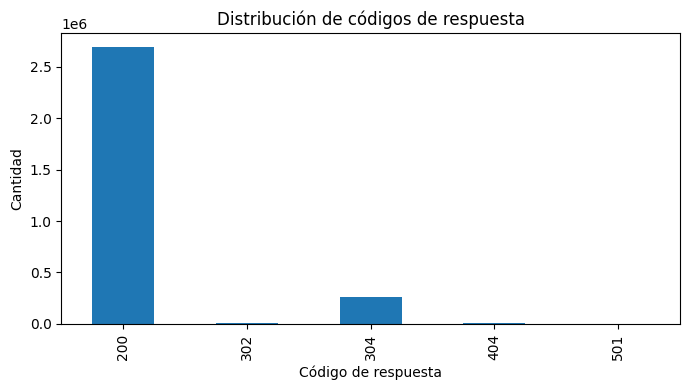

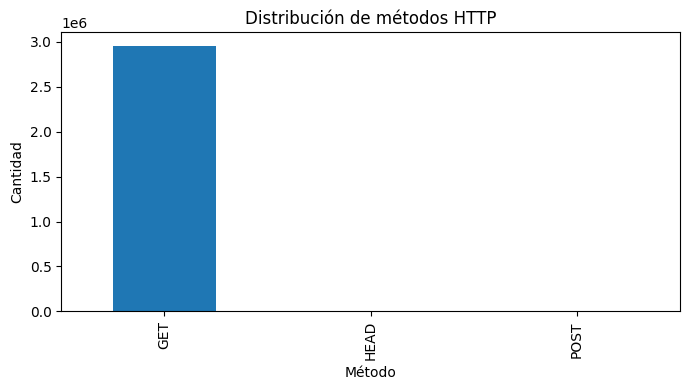

<Figure size 700x400 with 0 Axes>

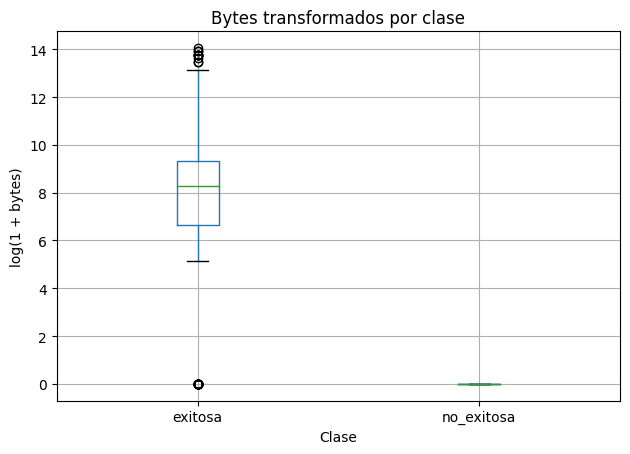

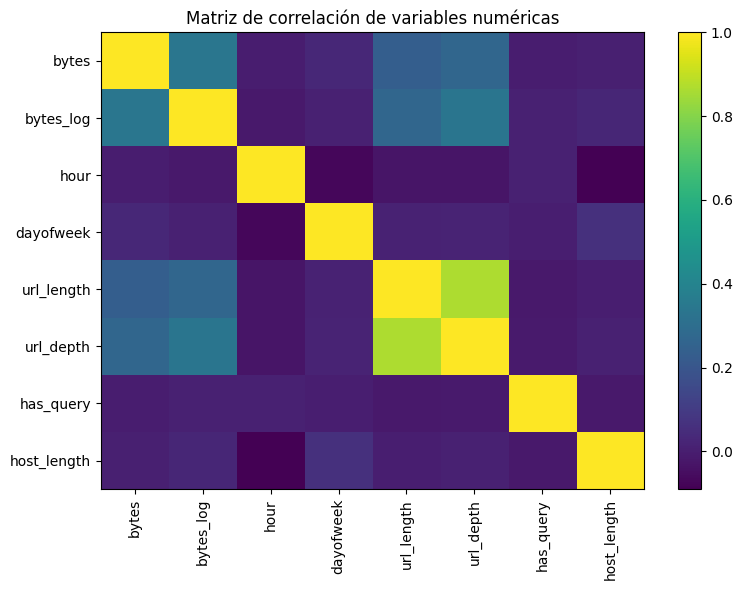

In [4]:
plt.figure(figsize=(7, 4))
datos["target"].value_counts().plot(kind="bar")
plt.title("Distribución de clases")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.savefig("outputs/grafico1_balance_clases.png", dpi=300)
plt.show()

plt.figure(figsize=(7, 4))
datos["response"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribución de códigos de respuesta")
plt.xlabel("Código de respuesta")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.savefig("outputs/grafico2_codigos_respuesta.png", dpi=300)
plt.show()

plt.figure(figsize=(7, 4))
datos["method"].value_counts().plot(kind="bar")
plt.title("Distribución de métodos HTTP")
plt.xlabel("Método")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.savefig("outputs/grafico3_metodos_http.png", dpi=300)
plt.show()

plt.figure(figsize=(7, 4))
datos_modelo.boxplot(column="bytes_log", by="target")
plt.title("Bytes transformados por clase")
plt.suptitle("")
plt.xlabel("Clase")
plt.ylabel("log(1 + bytes)")
plt.tight_layout()
plt.savefig("outputs/grafico4_bytes_por_clase.png", dpi=300)
plt.show()

correlacion = datos_modelo[["bytes", "bytes_log", "hour", "dayofweek", "url_length", "url_depth", "has_query", "host_length"]].corr()
plt.figure(figsize=(8, 6))
plt.imshow(correlacion, aspect="auto")
plt.colorbar()
plt.xticks(range(len(correlacion.columns)), correlacion.columns, rotation=90)
plt.yticks(range(len(correlacion.index)), correlacion.index)
plt.title("Matriz de correlación de variables numéricas")
plt.tight_layout()
plt.savefig("outputs/grafico5_matriz_correlacion.png", dpi=300)
plt.show()

## Inciso 2

In [5]:
X = datos_modelo.drop(columns="target")
y_texto = datos_modelo["target"]

codificador_y = LabelEncoder()
y = codificador_y.fit_transform(y_texto)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE
)

variables_numericas = ["bytes", "bytes_log", "hour", "dayofweek", "url_length", "url_depth", "has_query", "host_length"]
variables_categoricas = ["method", "extension_top"]

if "sparse_output" in inspect.signature(OneHotEncoder).parameters:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
else:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocesador = ColumnTransformer([
    ("num", StandardScaler(), variables_numericas),
    ("cat", onehot, variables_categoricas)
])

X_train_pre = preprocesador.fit_transform(X_train)
X_test_pre = preprocesador.transform(X_test)

print("Clases:", list(codificador_y.classes_))
print("Entrenamiento:", X_train_pre.shape)
print("Prueba:", X_test_pre.shape)

Clases: ['exitosa', 'no_exitosa']
Entrenamiento: (4500, 21)
Prueba: (1500, 21)


In [6]:
def crear_etiquetas_semisupervisadas(y_base, porcentaje, random_state):
    indices = np.arange(len(y_base))
    _, indices_etiquetados = train_test_split(
        indices,
        test_size=porcentaje,
        stratify=y_base,
        random_state=random_state
    )
    y_semi = np.full(y_base.shape, -1, dtype=int)
    y_semi[indices_etiquetados] = y_base[indices_etiquetados]
    return y_semi, indices_etiquetados

resumen_etiquetas = []
for porcentaje in LABELED_PERCENTAGES:
    y_semi, indices_etiquetados = crear_etiquetas_semisupervisadas(y_train, porcentaje, RANDOM_STATE + int(porcentaje * 100))
    resumen_etiquetas.append({
        "porcentaje_etiquetado": porcentaje,
        "datos_etiquetados": len(indices_etiquetados),
        "datos_no_etiquetados": int((y_semi == -1).sum())
    })

display(pd.DataFrame(resumen_etiquetas))

,porcentaje_etiquetado,datos_etiquetados,datos_no_etiquetados
0,0.05,225,4275
1,0.10,450,4050
2,0.20,900,3600


## Inciso 3

In [7]:
def calcular_metricas(y_real, y_pred):
    return {
        "accuracy": accuracy_score(y_real, y_pred),
        "precision_weighted": precision_score(y_real, y_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_real, y_pred, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y_real, y_pred, average="weighted", zero_division=0)
    }

def crear_random_forest():
    return RandomForestClassifier(
        n_estimators=120,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

def crear_self_training(threshold):
    estimador = crear_random_forest()
    parametros = {
        "threshold": threshold,
        "criterion": "threshold",
        "max_iter": 10,
        "verbose": False
    }
    if "estimator" in inspect.signature(SelfTrainingClassifier).parameters:
        parametros["estimator"] = estimador
    else:
        parametros["base_estimator"] = estimador
    return SelfTrainingClassifier(**parametros)

resultados = []
predicciones = {}

for porcentaje in LABELED_PERCENTAGES:
    y_semi, indices_etiquetados = crear_etiquetas_semisupervisadas(y_train, porcentaje, RANDOM_STATE + int(porcentaje * 100))
    X_etiquetado = X_train_pre[indices_etiquetados]
    y_etiquetado = y_train[indices_etiquetados]

    modelo_supervisado = crear_random_forest()
    modelo_supervisado.fit(X_etiquetado, y_etiquetado)
    pred = modelo_supervisado.predict(X_test_pre)
    id_modelo = f"supervisado_rf_{porcentaje}"
    predicciones[id_modelo] = pred
    fila = {
        "id_modelo": id_modelo,
        "modelo": "Supervisado RF",
        "porcentaje_etiquetado": porcentaje,
        "hiperparametro": "n_estimators=120",
        "datos_etiquetados": len(indices_etiquetados)
    }
    fila.update(calcular_metricas(y_test, pred))
    resultados.append(fila)

    for threshold in [0.75, 0.85, 0.95]:
        modelo_self = crear_self_training(threshold)
        modelo_self.fit(X_train_pre, y_semi)
        pred = modelo_self.predict(X_test_pre)
        id_modelo = f"self_training_{porcentaje}_{threshold}"
        predicciones[id_modelo] = pred
        fila = {
            "id_modelo": id_modelo,
            "modelo": "Self-Training RF",
            "porcentaje_etiquetado": porcentaje,
            "hiperparametro": f"threshold={threshold}",
            "datos_etiquetados": len(indices_etiquetados)
        }
        fila.update(calcular_metricas(y_test, pred))
        resultados.append(fila)

    for vecinos in [5, 10, 15]:
        modelo_label = LabelSpreading(kernel="knn", n_neighbors=vecinos, alpha=0.2, max_iter=40)
        modelo_label.fit(X_train_pre, y_semi)
        pred = modelo_label.predict(X_test_pre)
        id_modelo = f"label_spreading_{porcentaje}_{vecinos}"
        predicciones[id_modelo] = pred
        fila = {
            "id_modelo": id_modelo,
            "modelo": "Label Spreading",
            "porcentaje_etiquetado": porcentaje,
            "hiperparametro": f"n_neighbors={vecinos}",
            "datos_etiquetados": len(indices_etiquetados)
        }
        fila.update(calcular_metricas(y_test, pred))
        resultados.append(fila)

df_resultados = pd.DataFrame(resultados).sort_values(["f1_weighted", "accuracy"], ascending=False)
df_resultados.to_csv("outputs/resultados_modelos.csv", index=False)
display(df_resultados)

,id_modelo,modelo,porcentaje_etiquetado,hiperparametro,datos_etiquetados,accuracy,precision_weighted,recall_weighted,f1_weighted
0,supervisado_rf_0.05,Supervisado RF,0.05,n_estimators=120,225,0.996000,0.996169,0.996000,0.996039
1,self_training_0.05_0.75,Self-Training RF,0.05,threshold=0.75,225,0.996000,0.996169,0.996000,0.996039
2,self_training_0.05_0.85,Self-Training RF,0.05,threshold=0.85,225,0.996000,0.996169,0.996000,0.996039
3,self_training_0.05_0.95,Self-Training RF,0.05,threshold=0.95,225,0.996000,0.996169,0.996000,0.996039
7,supervisado_rf_0.1,Supervisado RF,0.10,n_estimators=120,450,0.996000,0.996169,0.996000,0.996039
8,self_training_0.1_0.75,Self-Training RF,0.10,threshold=0.75,450,0.996000,0.996169,0.996000,0.996039
9,self_training_0.1_0.85,Self-Training RF,0.10,threshold=0.85,450,0.996000,0.996169,0.996000,0.996039
10,self_training_0.1_0.95,Self-Training RF,0.10,threshold=0.95,450,0.996000,0.996169,0.996000,0.996039
14,supervisado_rf_0.2,Supervisado RF,0.20,n_estimators=120,900,0.996000,0.996169,0.996000,0.996039
15,self_training_0.2_0.75,Self-Training RF,0.20,threshold=0.75,900,0.996000,0.996169,0.996000,0.996039


In [8]:
mejores_por_modelo = df_resultados.sort_values("f1_weighted", ascending=False).groupby("modelo", as_index=False).first()
mejores_por_modelo.to_csv("outputs/mejores_modelos.csv", index=False)
display(mejores_por_modelo)

,modelo,id_modelo,porcentaje_etiquetado,hiperparametro,datos_etiquetados,accuracy,precision_weighted,recall_weighted,f1_weighted
0,Label Spreading,label_spreading_0.2_15,0.20,n_neighbors=15,900,0.996,0.996169,0.996,0.996039
1,Self-Training RF,self_training_0.1_0.95,0.10,threshold=0.95,450,0.996,0.996169,0.996,0.996039
2,Supervisado RF,supervisado_rf_0.05,0.05,n_estimators=120,225,0.996,0.996169,0.996,0.996039


## Inciso 4

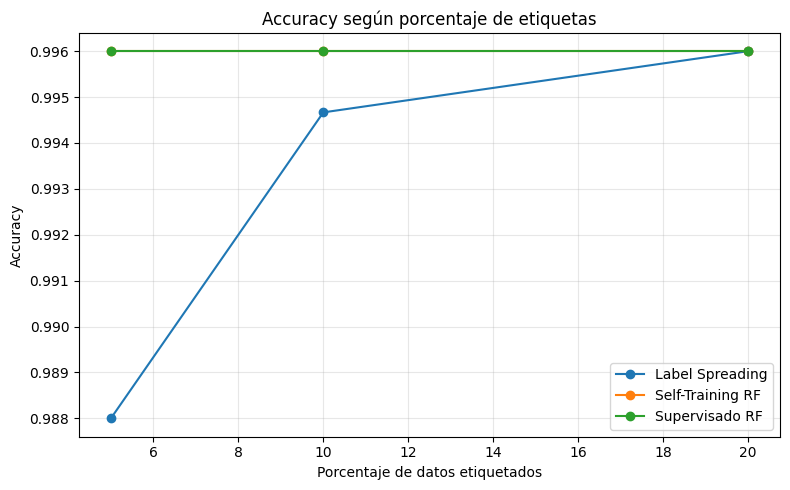

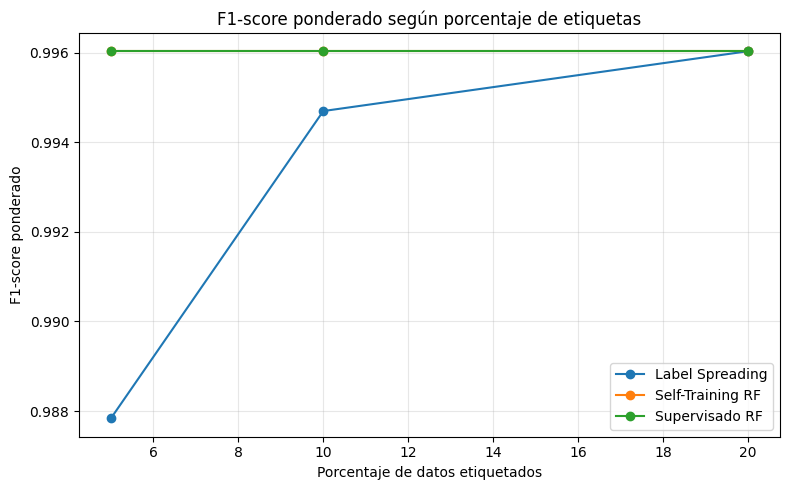

In [9]:
curvas = df_resultados.sort_values("f1_weighted", ascending=False).groupby(["modelo", "porcentaje_etiquetado"], as_index=False).first()

plt.figure(figsize=(8, 5))
for modelo, grupo in curvas.groupby("modelo"):
    grupo = grupo.sort_values("porcentaje_etiquetado")
    plt.plot(grupo["porcentaje_etiquetado"] * 100, grupo["accuracy"], marker="o", label=modelo)
plt.title("Accuracy según porcentaje de etiquetas")
plt.xlabel("Porcentaje de datos etiquetados")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/grafico6_accuracy_por_etiquetas.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
for modelo, grupo in curvas.groupby("modelo"):
    grupo = grupo.sort_values("porcentaje_etiquetado")
    plt.plot(grupo["porcentaje_etiquetado"] * 100, grupo["f1_weighted"], marker="o", label=modelo)
plt.title("F1-score ponderado según porcentaje de etiquetas")
plt.xlabel("Porcentaje de datos etiquetados")
plt.ylabel("F1-score ponderado")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/grafico7_f1_por_etiquetas.png", dpi=300)
plt.show()

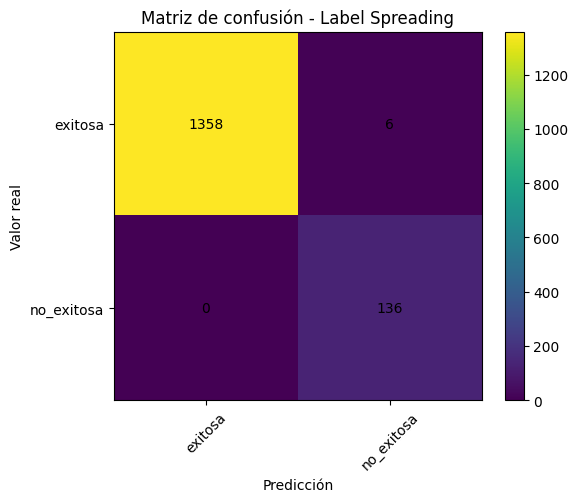

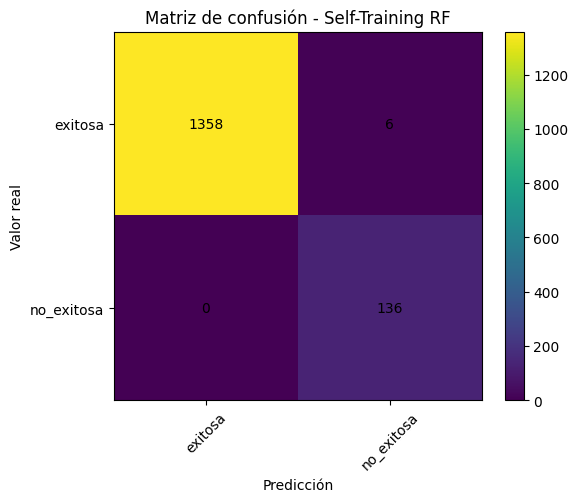

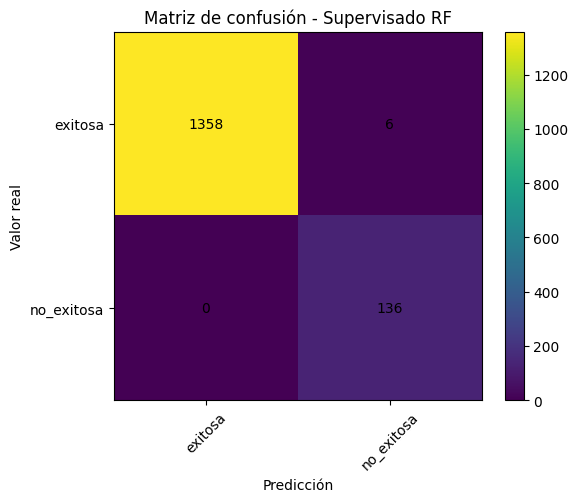

In [10]:
for _, fila in mejores_por_modelo.iterrows():
    pred = predicciones[fila["id_modelo"]]
    matriz = confusion_matrix(y_test, pred)
    etiquetas = codificador_y.classes_
    nombre = fila["modelo"].lower().replace(" ", "_").replace("-", "_")

    plt.figure(figsize=(6, 5))
    plt.imshow(matriz, interpolation="nearest")
    plt.title(f"Matriz de confusión - {fila['modelo']}")
    plt.colorbar()
    plt.xticks(np.arange(len(etiquetas)), etiquetas, rotation=45)
    plt.yticks(np.arange(len(etiquetas)), etiquetas)
    for i in range(matriz.shape[0]):
        for j in range(matriz.shape[1]):
            plt.text(j, i, matriz[i, j], ha="center", va="center")
    plt.xlabel("Predicción")
    plt.ylabel("Valor real")
    plt.tight_layout()
    plt.savefig(f"outputs/matriz_confusion_{nombre}.png", dpi=300)
    plt.show()

In [11]:
mejor = df_resultados.iloc[0]
y_pred_mejor = predicciones[mejor["id_modelo"]]
reporte = pd.DataFrame(classification_report(y_test, y_pred_mejor, target_names=codificador_y.classes_, output_dict=True, zero_division=0)).T
reporte.to_csv("outputs/reporte_clasificacion_mejor_modelo.csv")

print("Mejor modelo:", mejor["modelo"])
print("Porcentaje etiquetado:", mejor["porcentaje_etiquetado"])
print("Hiperparámetro:", mejor["hiperparametro"])
display(reporte)

Mejor modelo: Supervisado RF
Porcentaje etiquetado: 0.05
Hiperparámetro: n_estimators=120


,precision,recall,f1-score,support
exitosa,1.000000,0.995601,0.997796,1364.000
no_exitosa,0.957746,1.000000,0.978417,136.000
accuracy,0.996000,0.996000,0.996000,0.996
macro avg,0.978873,0.997801,0.988107,1500.000
weighted avg,0.996169,0.996000,0.996039,1500.000


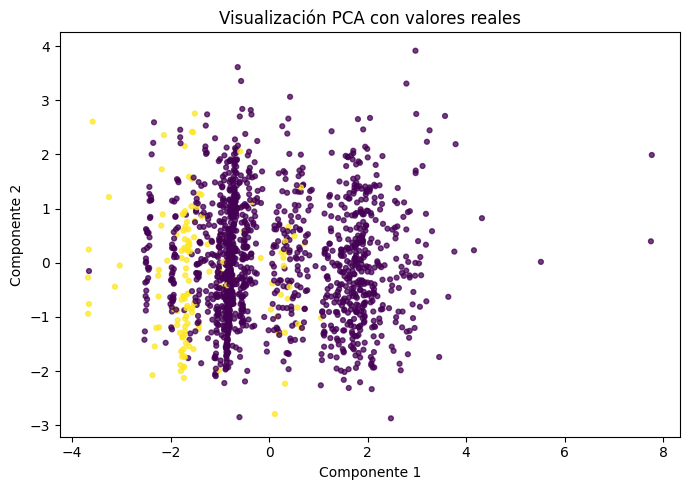

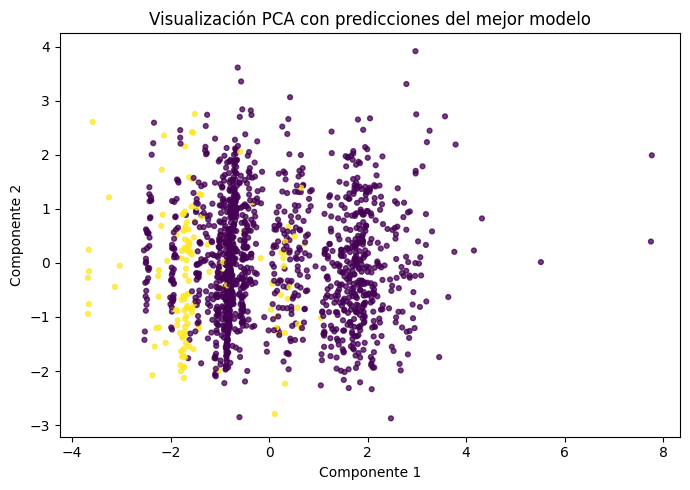

In [12]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coordenadas = pca.fit_transform(X_test_pre)

plt.figure(figsize=(7, 5))
plt.scatter(coordenadas[:, 0], coordenadas[:, 1], c=y_test, s=12, alpha=0.75)
plt.title("Visualización PCA con valores reales")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.tight_layout()
plt.savefig("outputs/grafico8_pca_valores_reales.png", dpi=300)
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(coordenadas[:, 0], coordenadas[:, 1], c=y_pred_mejor, s=12, alpha=0.75)
plt.title("Visualización PCA con predicciones del mejor modelo")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.tight_layout()
plt.savefig("outputs/grafico9_pca_predicciones.png", dpi=300)
plt.show()

## Inciso 5

In [13]:
resumen_final = pd.DataFrame({
    "aspecto": [
        "modelo_seleccionado",
        "porcentaje_etiquetado",
        "hiperparametro",
        "accuracy",
        "f1_weighted",
        "recall_weighted"
    ],
    "resultado": [
        mejor["modelo"],
        mejor["porcentaje_etiquetado"],
        mejor["hiperparametro"],
        mejor["accuracy"],
        mejor["f1_weighted"],
        mejor["recall_weighted"]
    ]
})

resumen_final.to_csv("outputs/resumen_final.csv", index=False)
display(resumen_final)

,aspecto,resultado
0,modelo_seleccionado,Supervisado RF
1,porcentaje_etiquetado,0.05
2,hiperparametro,n_estimators=120
3,accuracy,0.996
4,f1_weighted,0.996039
5,recall_weighted,0.996
